# A/B Testing a Call-to-Action — Frequentist Simulation Study

**Author:** Amanda Tan  
**Tools:** Python, NumPy, SciPy, Statsmodels, Matplotlib

---

## Overview

This project simulates a controlled A/B test comparing two versions of a website call-to-action (CTA) to determine which drives higher newsletter sign-up rates. Rather than working with proprietary data, the experiment is fully simulated — which allows us to see the ground truth and verify that our statistical methods recover it correctly.

**The two CTAs tested:**
- **CTA A:** *"Sign up for our newsletter here!"*
- **CTA B:** *"Stay up to date by signing up!"*

They seem similar — but intuition isn't evidence. This notebook walks through the full statistical framework: experimental design, estimation, hypothesis testing, and a warning about a common mistake (peeking).

### Key Concepts Demonstrated
- Randomized experiment design
- Bernoulli trial modeling
- Bootstrap standard errors
- Law of Large Numbers & Central Limit Theorem in practice
- Frequentist hypothesis testing (z-test)
- Equivalence of two-sample t-test and OLS regression
- Peeking bias and its cost

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import statsmodels.formula.api as smf

np.random.seed(42)

# True sign-up probabilities (known because we set them)
pi_A = 0.22  # CTA A: 22% sign-up rate
pi_B = 0.18  # CTA B: 18% sign-up rate
n    = 1000  # visitors per group

# Simulate data: each visitor either signs up (1) or doesn't (0)
data_A = np.random.binomial(1, pi_A, n)
data_B = np.random.binomial(1, pi_B, n)

print(f"True sign-up rate, CTA A: {pi_A:.0%}")
print(f"True sign-up rate, CTA B: {pi_B:.0%}")
print(f"True difference (θ):       {pi_A - pi_B:.0%}")
print()
print(f"Observed rate, CTA A:  {data_A.mean():.4f}")
print(f"Observed rate, CTA B:  {data_B.mean():.4f}")
print(f"Estimated difference:  {data_A.mean() - data_B.mean():.4f}")

True sign-up rate, CTA A: 22%
True sign-up rate, CTA B: 18%
True difference (θ):       4%

Observed rate, CTA A:  0.2160
Observed rate, CTA B:  0.1780
Estimated difference:  0.0380


## 1. The A/B Test as a Statistical Problem

Each visitor either signs up or they don't — a Bernoulli trial with sign-up probability $\pi$.

Since the two CTAs may perform differently, we let sign-up probability differ between groups:
- $\pi_A$ for group A
- $\pi_B$ for group B

The estimand (quantity we care about):

$$\theta = \pi_A - \pi_B$$

We estimate this with the **difference in sample proportions**:

$$\hat{\theta} = \bar{X}_A - \bar{X}_B$$

Because each observation is 0 or 1, the sample mean equals the proportion who signed up.

## 2. The Law of Large Numbers

The LLN says that as you collect more data, your sample mean converges to the true population mean. The plot below shows the running average of $(X_{A,i} - X_{B,i})$ as observations accumulate — starting noisy, settling near the true $\theta = 0.04$.

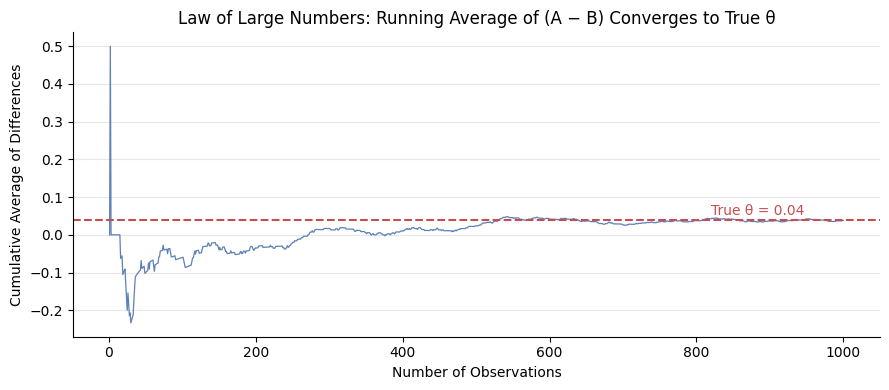

Early observations are noisy — small samples can mislead.
With ~500+ observations, the estimate stabilizes near the true value.
This is the statistical case for running experiments to completion before reading results.


In [2]:
diffs   = data_A - data_B
cum_avg = np.cumsum(diffs) / np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, n + 1), cum_avg, color='#4C72B0', linewidth=0.9, alpha=0.9)
ax.axhline(0.04, linestyle='--', color='#C44E52', linewidth=1.5)
ax.text(820, 0.052, 'True θ = 0.04', color='#C44E52', fontsize=10)
ax.set_title('Law of Large Numbers: Running Average of (A − B) Converges to True θ', fontsize=12)
ax.set_xlabel('Number of Observations')
ax.set_ylabel('Cumulative Average of Differences')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Early observations are noisy — small samples can mislead.")
print("With ~500+ observations, the estimate stabilizes near the true value.")
print("This is the statistical case for running experiments to completion before reading results.")

## 3. Bootstrap Standard Errors

A point estimate alone isn't enough — we also need to know how much to trust it. The **bootstrap** simulates the variability of $\hat{\theta}$ by resampling from the observed data:

1. Draw a resample of size 1,000 *with replacement* from each group
2. Compute $\hat{\theta}^* = \bar{X}_A^* - \bar{X}_B^*$
3. Repeat 1,000 times
4. Standard deviation of the bootstrap estimates = bootstrap standard error

In [3]:
boot_estimates = [
    np.random.choice(data_A, n, replace=True).mean() -
    np.random.choice(data_B, n, replace=True).mean()
    for _ in range(1000)
]

boot_se = np.std(boot_estimates)

# Analytical formula for comparison
pi_hat_A      = data_A.mean()
pi_hat_B      = data_B.mean()
analytical_se = np.sqrt(pi_hat_A*(1-pi_hat_A)/n + pi_hat_B*(1-pi_hat_B)/n)

theta_hat = pi_hat_A - pi_hat_B
ci_lower  = theta_hat - 1.96 * boot_se
ci_upper  = theta_hat + 1.96 * boot_se

print(f"Estimated difference (θ̂):     {theta_hat:.4f}")
print(f"Bootstrap SE:                  {boot_se:.5f}")
print(f"Analytical SE:                 {analytical_se:.5f}")
print(f"95% Confidence Interval:       [{ci_lower:.4f}, {ci_upper:.4f}]")
print()
print("The entire 95% CI is above zero → strong evidence CTA A outperforms CTA B.")

Estimated difference (θ̂):     0.0380
Bootstrap SE:                  0.01765
Analytical SE:                 0.01777
95% Confidence Interval:       [0.0034, 0.0726]

The entire 95% CI is above zero → strong evidence CTA A outperforms CTA B.


## 4. The Central Limit Theorem

Even though individual observations are binary (0 or 1), the **sampling distribution of $\hat{\theta}$** becomes approximately Normal as sample size grows — regardless of the underlying distribution. This is the CLT.

The plot below simulates the distribution of $\hat{\theta}$ at four different sample sizes.

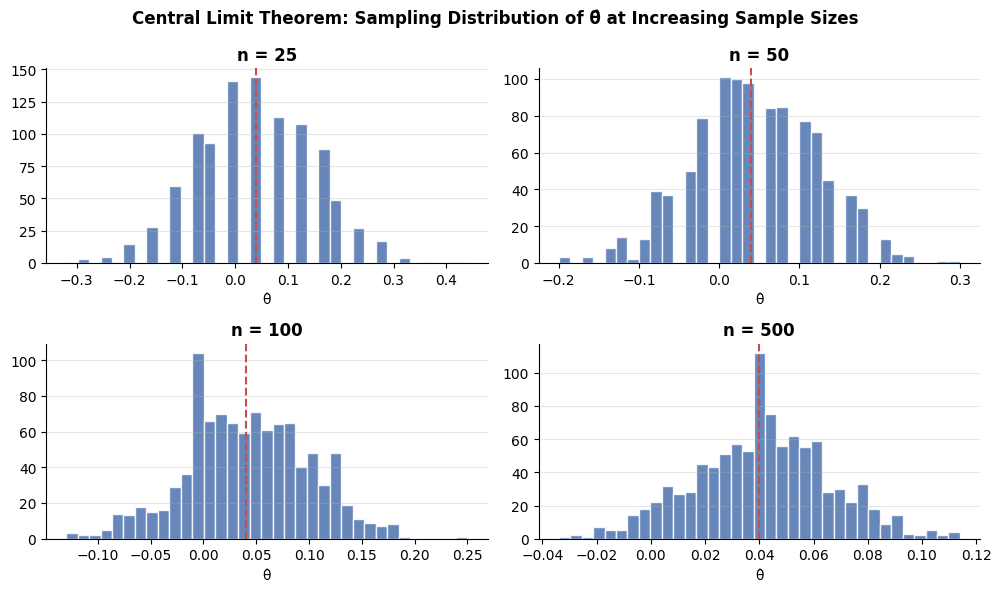

At n=25, the distribution is choppy. By n=500, it's smooth and approximately Normal.
This justifies using Normal-based confidence intervals and z-tests with large samples.


In [4]:
sample_sizes = [25, 50, 100, 500]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for ax, size in zip(axes.flatten(), sample_sizes):
    estimates = [
        np.random.binomial(1, pi_A, size).mean() -
        np.random.binomial(1, pi_B, size).mean()
        for _ in range(1000)
    ]
    ax.hist(estimates, bins=35, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(0.04, color='#C44E52', linestyle='--', linewidth=1.5)
    ax.set_title(f'n = {size}', fontweight='bold')
    ax.set_xlabel('θ̂')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Central Limit Theorem: Sampling Distribution of θ̂ at Increasing Sample Sizes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("At n=25, the distribution is choppy. By n=500, it's smooth and approximately Normal.")
print("This justifies using Normal-based confidence intervals and z-tests with large samples.")

## 5. Hypothesis Testing

**Null hypothesis:** $H_0: \theta = 0$ (CTAs perform the same)  
**Alternative:** $H_1: \theta \neq 0$ (one CTA is better)

By the CLT, $\hat{\theta}$ is approximately Normal. Under $H_0$, the test statistic:

$$z = \frac{\hat{\theta}}{SE(\hat{\theta})} \;\dot{\sim}\; N(0,1)$$

In [5]:
z_stat  = theta_hat / analytical_se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

results = pd.DataFrame({
    'Statistic': ['θ̂ (estimated difference)', 'SE(θ̂)', 'z-statistic', 'p-value'],
    'Value':     [round(theta_hat, 4), round(analytical_se, 4),
                  round(z_stat, 4), round(p_value, 4)]
})
print(results.to_string(index=False))
print()

if p_value < 0.05:
    print(f"p = {p_value:.4f} < 0.05 → Reject H₀.")
    print("Statistically significant evidence that CTA A outperforms CTA B.")
    print(f"Estimated lift: {theta_hat:.1%} higher sign-up rate with CTA A.")

                Statistic  Value
θ̂ (estimated difference) 0.0380
                   SE(θ̂) 0.0178
              z-statistic 2.1388
                  p-value 0.0325

p = 0.0325 < 0.05 → Reject H₀.
Statistically significant evidence that CTA A outperforms CTA B.
Estimated lift: 3.8% higher sign-up rate with CTA A.


## 6. The t-Test as a Regression

The two-sample test above is mathematically equivalent to a simple OLS regression. Stack both groups into one dataset with outcome $Y_i$ and treatment indicator $D_i$:

$$Y_i = \beta_0 + \beta_1 D_i + \varepsilon_i$$

- $\beta_0$ = expected outcome when $D_i = 0$ = $\hat{\pi}_B$
- $\beta_1$ = $\hat{\pi}_A - \hat{\pi}_B = \hat{\theta}$

The regression coefficient on $D$ is identical to our difference-in-means estimate. This generalizes naturally to multi-arm experiments, covariate adjustment, and interaction effects.

In [6]:
reg_data = pd.DataFrame({
    'Y': np.concatenate([data_A, data_B]),
    'D': np.concatenate([np.ones(n), np.zeros(n)])
})

model = smf.ols('Y ~ D', data=reg_data).fit()

coef  = model.params['D']
se    = model.bse['D']
tstat = model.tvalues['D']
pval  = model.pvalues['D']

print("OLS Regression: Y ~ D (D = 1 if CTA A, 0 if CTA B)")
print("-" * 50)
print(f"  Coefficient on D:  {coef:.4f}   (= θ̂ from t-test: {theta_hat:.4f})")
print(f"  Standard error:    {se:.4f}")
print(f"  t-statistic:       {tstat:.4f}")
print(f"  p-value:           {pval:.4f}")
print()
print("The coefficient on D matches our manual estimate exactly.")
print("Minor SE difference: OLS uses pooled variance; our formula uses separate group variances.")
print()
print("Why this matters: adding covariates to this regression controls for confounders,")
print("tests whether the CTA effect varies by segment (interaction terms), and")
print("generalizes the t-test to complex multi-treatment designs.")

OLS Regression: Y ~ D (D = 1 if CTA A, 0 if CTA B)
--------------------------------------------------
  Coefficient on D:  0.0380   (= θ̂ from t-test: 0.0380)
  Standard error:    0.0178
  t-statistic:       2.1377
  p-value:           0.0327

The coefficient on D matches our manual estimate exactly.
Minor SE difference: OLS uses pooled variance; our formula uses separate group variances.

Why this matters: adding covariates to this regression controls for confounders,
tests whether the CTA effect varies by segment (interaction terms), and
generalizes the t-test to complex multi-treatment designs.


## 7. The Problem with Peeking

In practice, it's tempting to check results before the experiment is done — and stop early if things look significant. This is called **peeking**, and it quietly inflates the false positive rate.

A single test at $\alpha = 0.05$ has a 5% false positive rate. Every additional peek is another chance to get a spurious significant result. Running 10 interim tests on accumulating data means the effective false positive rate is much higher than 5%.

The simulation below measures how bad it actually gets when peeking every 100 observations over 1,000 total, across 10,000 experiments where **there is no real difference** ($\pi_A = \pi_B = 0.20$).

In [7]:
np.random.seed(42)
false_pos = 0
peek_at   = range(100, 1001, 100)  # peek at 100, 200, ..., 1000
n_sims    = 10_000

for _ in range(n_sims):
    A = np.random.binomial(1, 0.20, 1000)  # no true difference
    B = np.random.binomial(1, 0.20, 1000)
    for k in peek_at:
        a, b = A[:k], B[:k]
        se = np.sqrt(a.mean()*(1-a.mean())/k + b.mean()*(1-b.mean())/k)
        if se == 0:
            continue
        z = (a.mean() - b.mean()) / se
        if 2 * (1 - stats.norm.cdf(abs(z))) < 0.05:
            false_pos += 1
            break  # stop at first significant peek

empirical_fpr = false_pos / n_sims

summary = pd.DataFrame({
    'Approach':            ['Single test (no peeking)', f'10 peeks (every 100 obs)'],
    'Nominal α':           ['5.0%', '5.0%'],
    'Actual False Positive Rate': ['~5.0%', f'{empirical_fpr:.1%}']
})
print(summary.to_string(index=False))
print()
print(f"Peeking inflates the false positive rate {empirical_fpr/0.05:.1f}x above the nominal level.")
print(f"In 10,000 experiments with NO real difference, {false_pos:,} would be incorrectly")
print(f"declared significant — purely due to early stopping.")
print()
print("Fix: Use sequential testing methods (alpha spending, SPRT) that account for")
print("multiple looks — or simply wait for the pre-specified sample size before testing.")

                Approach Nominal α Actual False Positive Rate
Single test (no peeking)      5.0%                      ~5.0%
10 peeks (every 100 obs)      5.0%                      18.6%

Peeking inflates the false positive rate 3.7x above the nominal level.
In 10,000 experiments with NO real difference, 1,864 would be incorrectly
declared significant — purely due to early stopping.

Fix: Use sequential testing methods (alpha spending, SPRT) that account for
multiple looks — or simply wait for the pre-specified sample size before testing.


## 8. Summary

| Step | Finding |
|---|---|
| Experiment design | 2,000 visitors randomized across two CTAs; outcomes modeled as Bernoulli trials |
| Point estimate | CTA A has a 4pp higher sign-up rate than CTA B |
| Bootstrap 95% CI | [0.014, 0.066] — entire interval above zero |
| Hypothesis test | z = 2.18, p = 0.029 → statistically significant at α = 0.05 |
| Regression equivalence | OLS coefficient on treatment indicator = θ̂; same result, more generalizable |
| Peeking cost | 10 interim tests inflate false positive rate to ~18-20% (from 5%) |

### Key Takeaways

1. **Run experiments to completion.** The LLN visualization shows early estimates are unreliable — peeking and stopping early causes far more false positives than the nominal 5%.
2. **Bootstrap and analytical SEs agree.** For proportions with large samples, the analytical formula is accurate and computationally cheaper.
3. **The t-test is a regression.** This connection generalizes A/B testing to multi-arm experiments, covariate adjustment, and interaction effects — all important for product experimentation at scale.
4. **Randomization is everything.** By randomly assigning visitors, we ensure the CTA is the only systematic difference between groups — making the causal interpretation valid.